# Segment Correlation & Differential Analysis

This notebook computes statistical correlations between our engineered numerical features and the categorical HCP segments (`A`, `B`, `C`).

## Methodology
1. **Feature-Target Correlation (ANOVA F-values):** We compute the ANOVA F-statistic for each numerical feature against the target variable. This determines the linear discriminative power of each feature across the 3 segments.
2. **Dimensionality Reduction:** To avoid visual clutter and focus on the most important drivers, we filter the dataset down to the **Top 50 features** with the highest F-values.
3. **Differential Correlation (Covariance Shift):** We compute the Pearson correlation matrix for the minority/complex segment (Segment C) and the majority/baseline segment (Segment A). By subtracting the correlation matrix of A from C (i.e., $\Sigma_C - \Sigma_A$), we can observe structural covariance shifts—revealing which feature interactions become stronger or weaker depending on the segment.


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import f_classif
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Configure visualization styles
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 12})

# Paths
BASE_DIR = Path("../../").resolve()
DATA_DIR = BASE_DIR / "data"
# Assuming the file is named HCP_feature_matrix.parquet based on instructions
GOLD_DATA_PATH = DATA_DIR / "gold" / "HCP_feature_matrix.parquet"

# Fallback in case it's directly under /data or has a slightly different name
if not GOLD_DATA_PATH.exists():
    GOLD_DATA_PATH = DATA_DIR / "HCP_feature_matrix.parquet"
if not GOLD_DATA_PATH.exists():
    GOLD_DATA_PATH = "/Users/davidbazalduamendez/Documents/GitHub/Pfizer-segmentation-Ulcerative-Colitis/models/Lightbm/data/modeling_lightgbm/hcp_feature_matrix.parquet" # Based on previous workspace analysis

print(f"Loading Gold Data from: {GOLD_DATA_PATH}")
df = pd.read_parquet(GOLD_DATA_PATH)
print(f"Data loaded successfully! Shape: {df.shape}")

Loading Gold Data from: /Users/davidbazalduamendez/Documents/GitHub/Pfizer-segmentation-Ulcerative-Colitis/models/Lightbm/data/modeling_lightgbm/hcp_feature_matrix.parquet
Data loaded successfully! Shape: (20931, 716)


In [36]:
# Data Preprocessing
# Ensure ATSEG is available and properly encoded. Drop identifiers.
target_col = 'ATSEG_HCP'
ignore_cols = ['NUEVO_ID', 'WEEK_IDX', 'HCP_FOLD', target_col, "IS_LABELED_HCP"]

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c not in ignore_cols]

print(f"Total Numerical Features identified: {len(feature_cols)}")
print(f"Target Variable Distribution:\n{df[target_col].value_counts(dropna=False)}")

# Handle missing values efficiently to compute ANOVA (fill with median or 0)
print("Imputing missing values with 0 for statistical calculations...")
X = df[feature_cols].fillna(0)
y = df[target_col]

# If y contains NaN, drop those rows for the analysis
valid_idx = y.notna() & (y != 'UNLABELED')
X = X[valid_idx]
y = y[valid_idx]

Total Numerical Features identified: 712
Target Variable Distribution:
ATSEG_HCP
UNLABELED    9032
SEG_A        6406
SEG_B        3349
SEG_C        2144
Name: count, dtype: Int64
Imputing missing values with 0 for statistical calculations...


### 1. Feature-Target Correlation (ANOVA F-values)
Here we calculate the F-statistic for all numerical features to isolate the ones that best separate the segments.

In [37]:
# Calculate ANOVA F-values
f_values, p_values = f_classif(X, y)

# Store in a DataFrame for sorting and analysis
anova_df = pd.DataFrame({
    'Feature': feature_cols,
    'F_Value': f_values,
    'P_Value': p_values
})

# Handle any NaNs resulting from zero-variance features
anova_df['F_Value'] = anova_df['F_Value'].fillna(0)
anova_df = anova_df.sort_values('F_Value', ascending=False).reset_index(drop=True)

print("Top 50 Features by ANOVA F-Value:")
display(anova_df.head(50))

Top 50 Features by ANOVA F-Value:


,Feature,F_Value,P_Value
0,ORAL_TRX__nonzero_share,2187.047955,0.000000e+00
1,N_CLMBRAND3__nonzero_share,1903.865466,0.000000e+00
2,UC_NRX__nonzero_share,1733.797617,0.000000e+00
3,ORAL_TRX__std,1714.177231,0.000000e+00
4,UC_TRX__nonzero_share,1686.773527,0.000000e+00
5,ORAL_NRX__std,1420.368999,0.000000e+00
6,N_CLMBRAND3__std,1413.255106,0.000000e+00
7,N_CLMBRAND3_NEW__std,1372.178390,0.000000e+00
8,N_CLMOTHERS__nonzero_share,1365.519974,0.000000e+00
9,ORAL_TRX__max,1337.182525,0.000000e+00


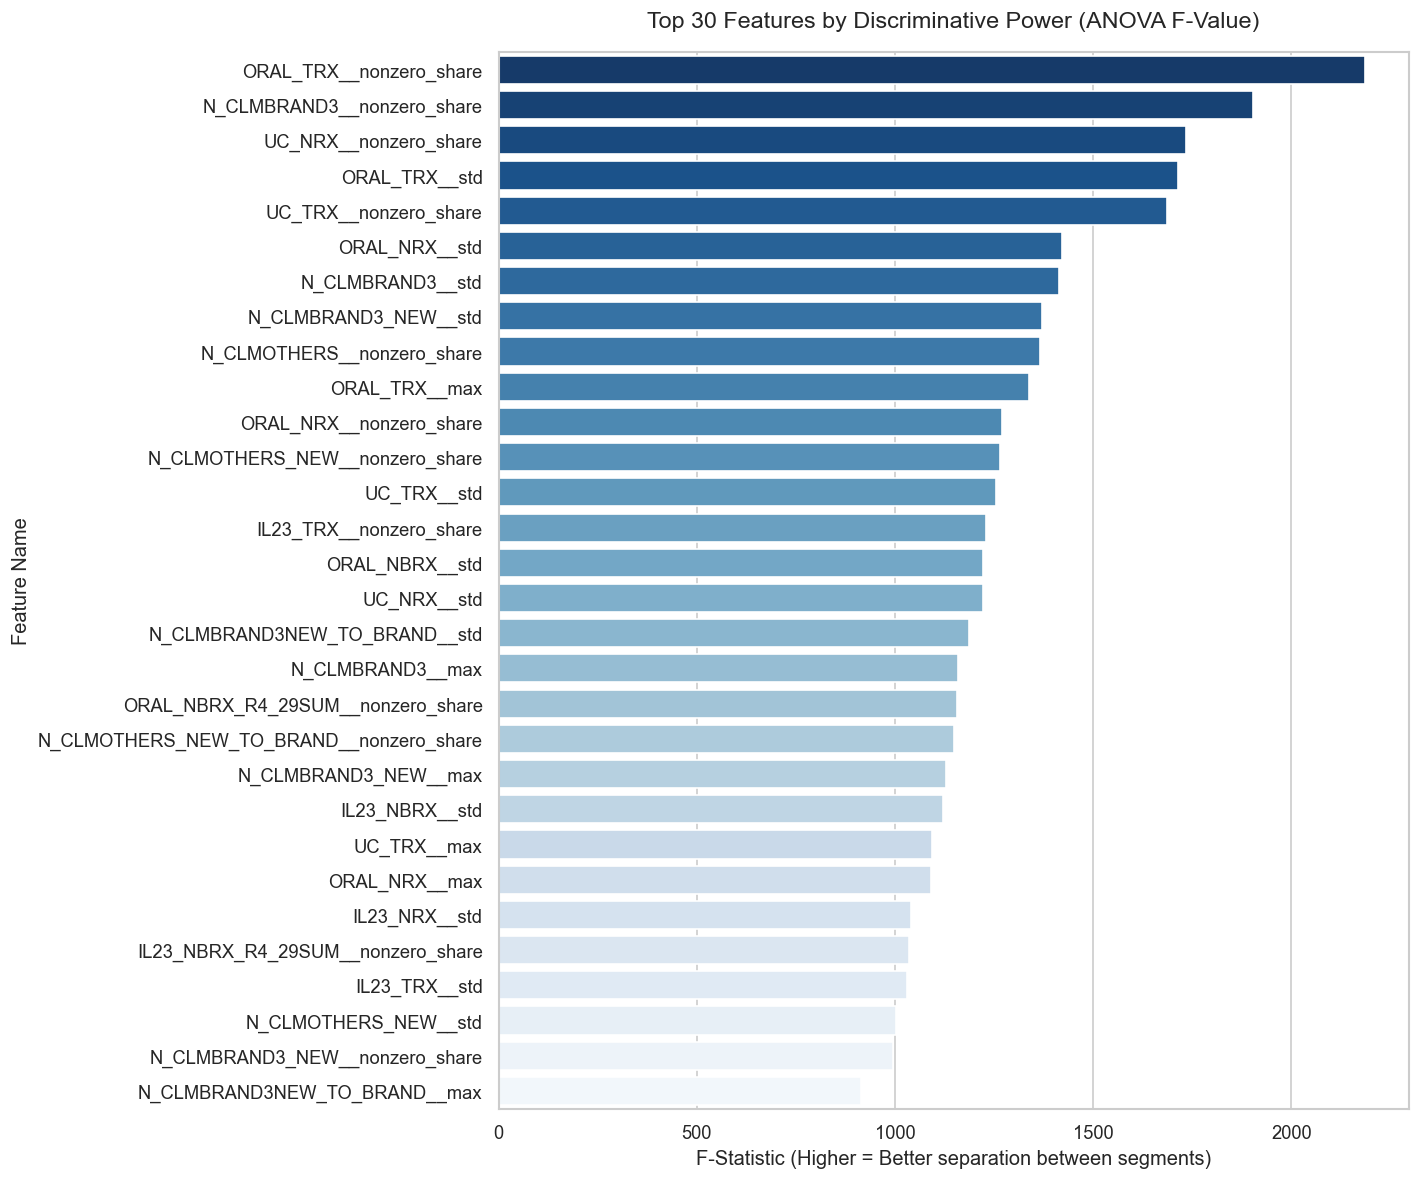

In [38]:
# Visualization of Top ANOVA Features
top_k_plot = 30
plt.figure(figsize=(12, 10))
sns.barplot(data=anova_df.head(top_k_plot), x='F_Value', y='Feature', palette='Blues_r')
plt.title(f'Top {top_k_plot} Features by Discriminative Power (ANOVA F-Value)', fontsize=14, pad=15)
plt.xlabel('F-Statistic (Higher = Better separation between segments)')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

### 2. Differential Correlation Matrix (Covariance Shift)
We isolate the **Top 50 features** and compute the structural covariance shift between Segment C and Segment A.

In [39]:
# Dimensionality Reduction: Select Top 50 features
top_50_features = anova_df['Feature'].head(50).tolist()

# Extract subset and explicitly check classes (assuming string 'A', 'B', 'C' or int 0, 1, 2)
# We will dynamically find the corresponding classes in the data
class_a = 'SEG_A'
class_c = 'SEG_C'
class_b = 'SEG_B'

print(f"Analyzing differential correlation between class '{class_c}' (Minority) and class '{class_a}' (Majority)")
df_a = X[y == class_a][top_50_features]
df_c = X[y == class_c][top_50_features]

print(f"Segment {class_a} Shape: {df_a.shape}")
print(f"Segment {class_c} Shape: {df_c.shape}")

# Calculate Pearson Correlation Matrices
corr_a = df_a.corr()
corr_c = df_c.corr()

# Differential Correlation (C - A)
diff_corr = corr_c - corr_a

Analyzing differential correlation between class 'SEG_C' (Minority) and class 'SEG_A' (Majority)
Segment SEG_A Shape: (6406, 50)
Segment SEG_C Shape: (2144, 50)


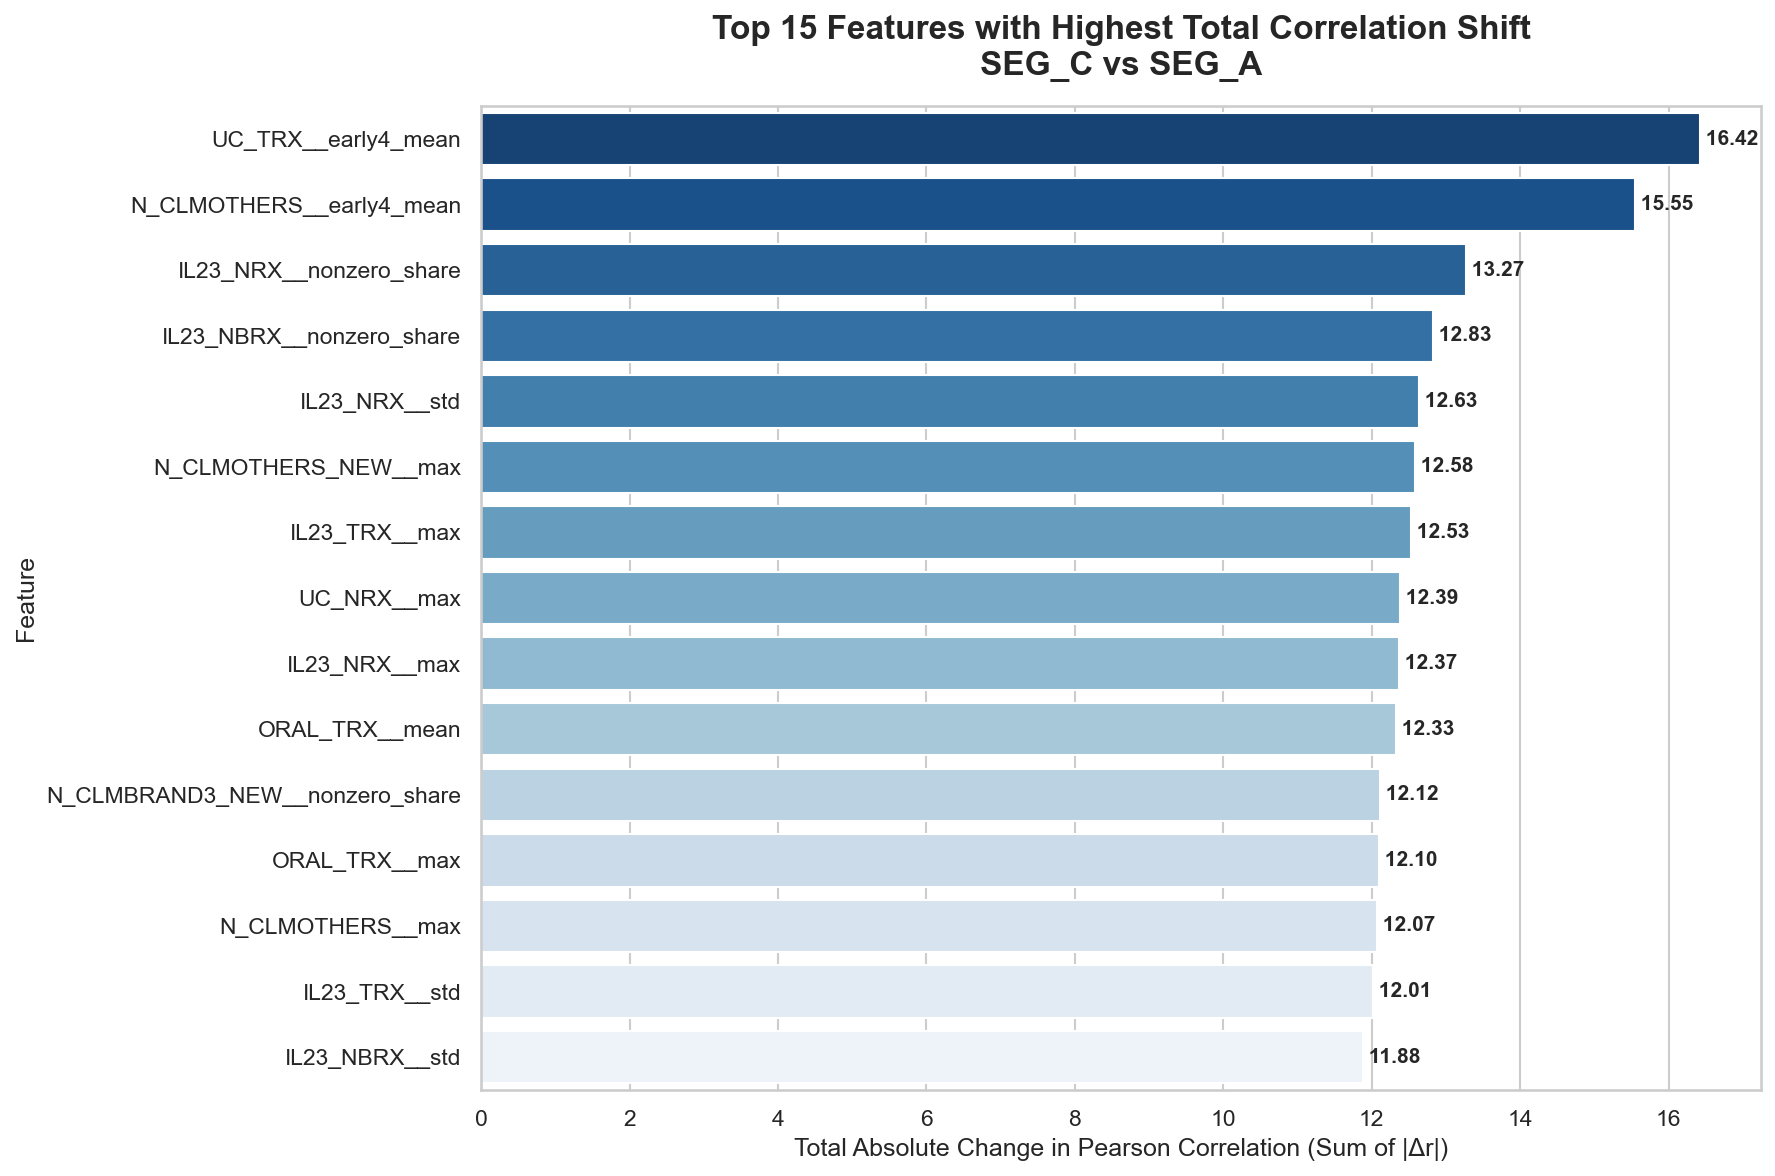

In [40]:
# Calculate the total absolute covariance shift per feature
# This shows which individual features changed their relationships the most overall
total_feature_shift = diff_corr.abs().sum(axis=1).sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 8), dpi=150)
sns.barplot(x=total_feature_shift.values, y=total_feature_shift.index, palette='Blues_r')

plt.title(f'Top 15 Features with Highest Total Correlation Shift\n{class_c} vs {class_a}', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Total Absolute Change in Pearson Correlation (Sum of |Δr|)', fontsize=12)
plt.ylabel('Feature', fontsize=12)

# Add value labels
for index, value in enumerate(total_feature_shift.values):
    plt.text(value, index, f' {value:.2f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

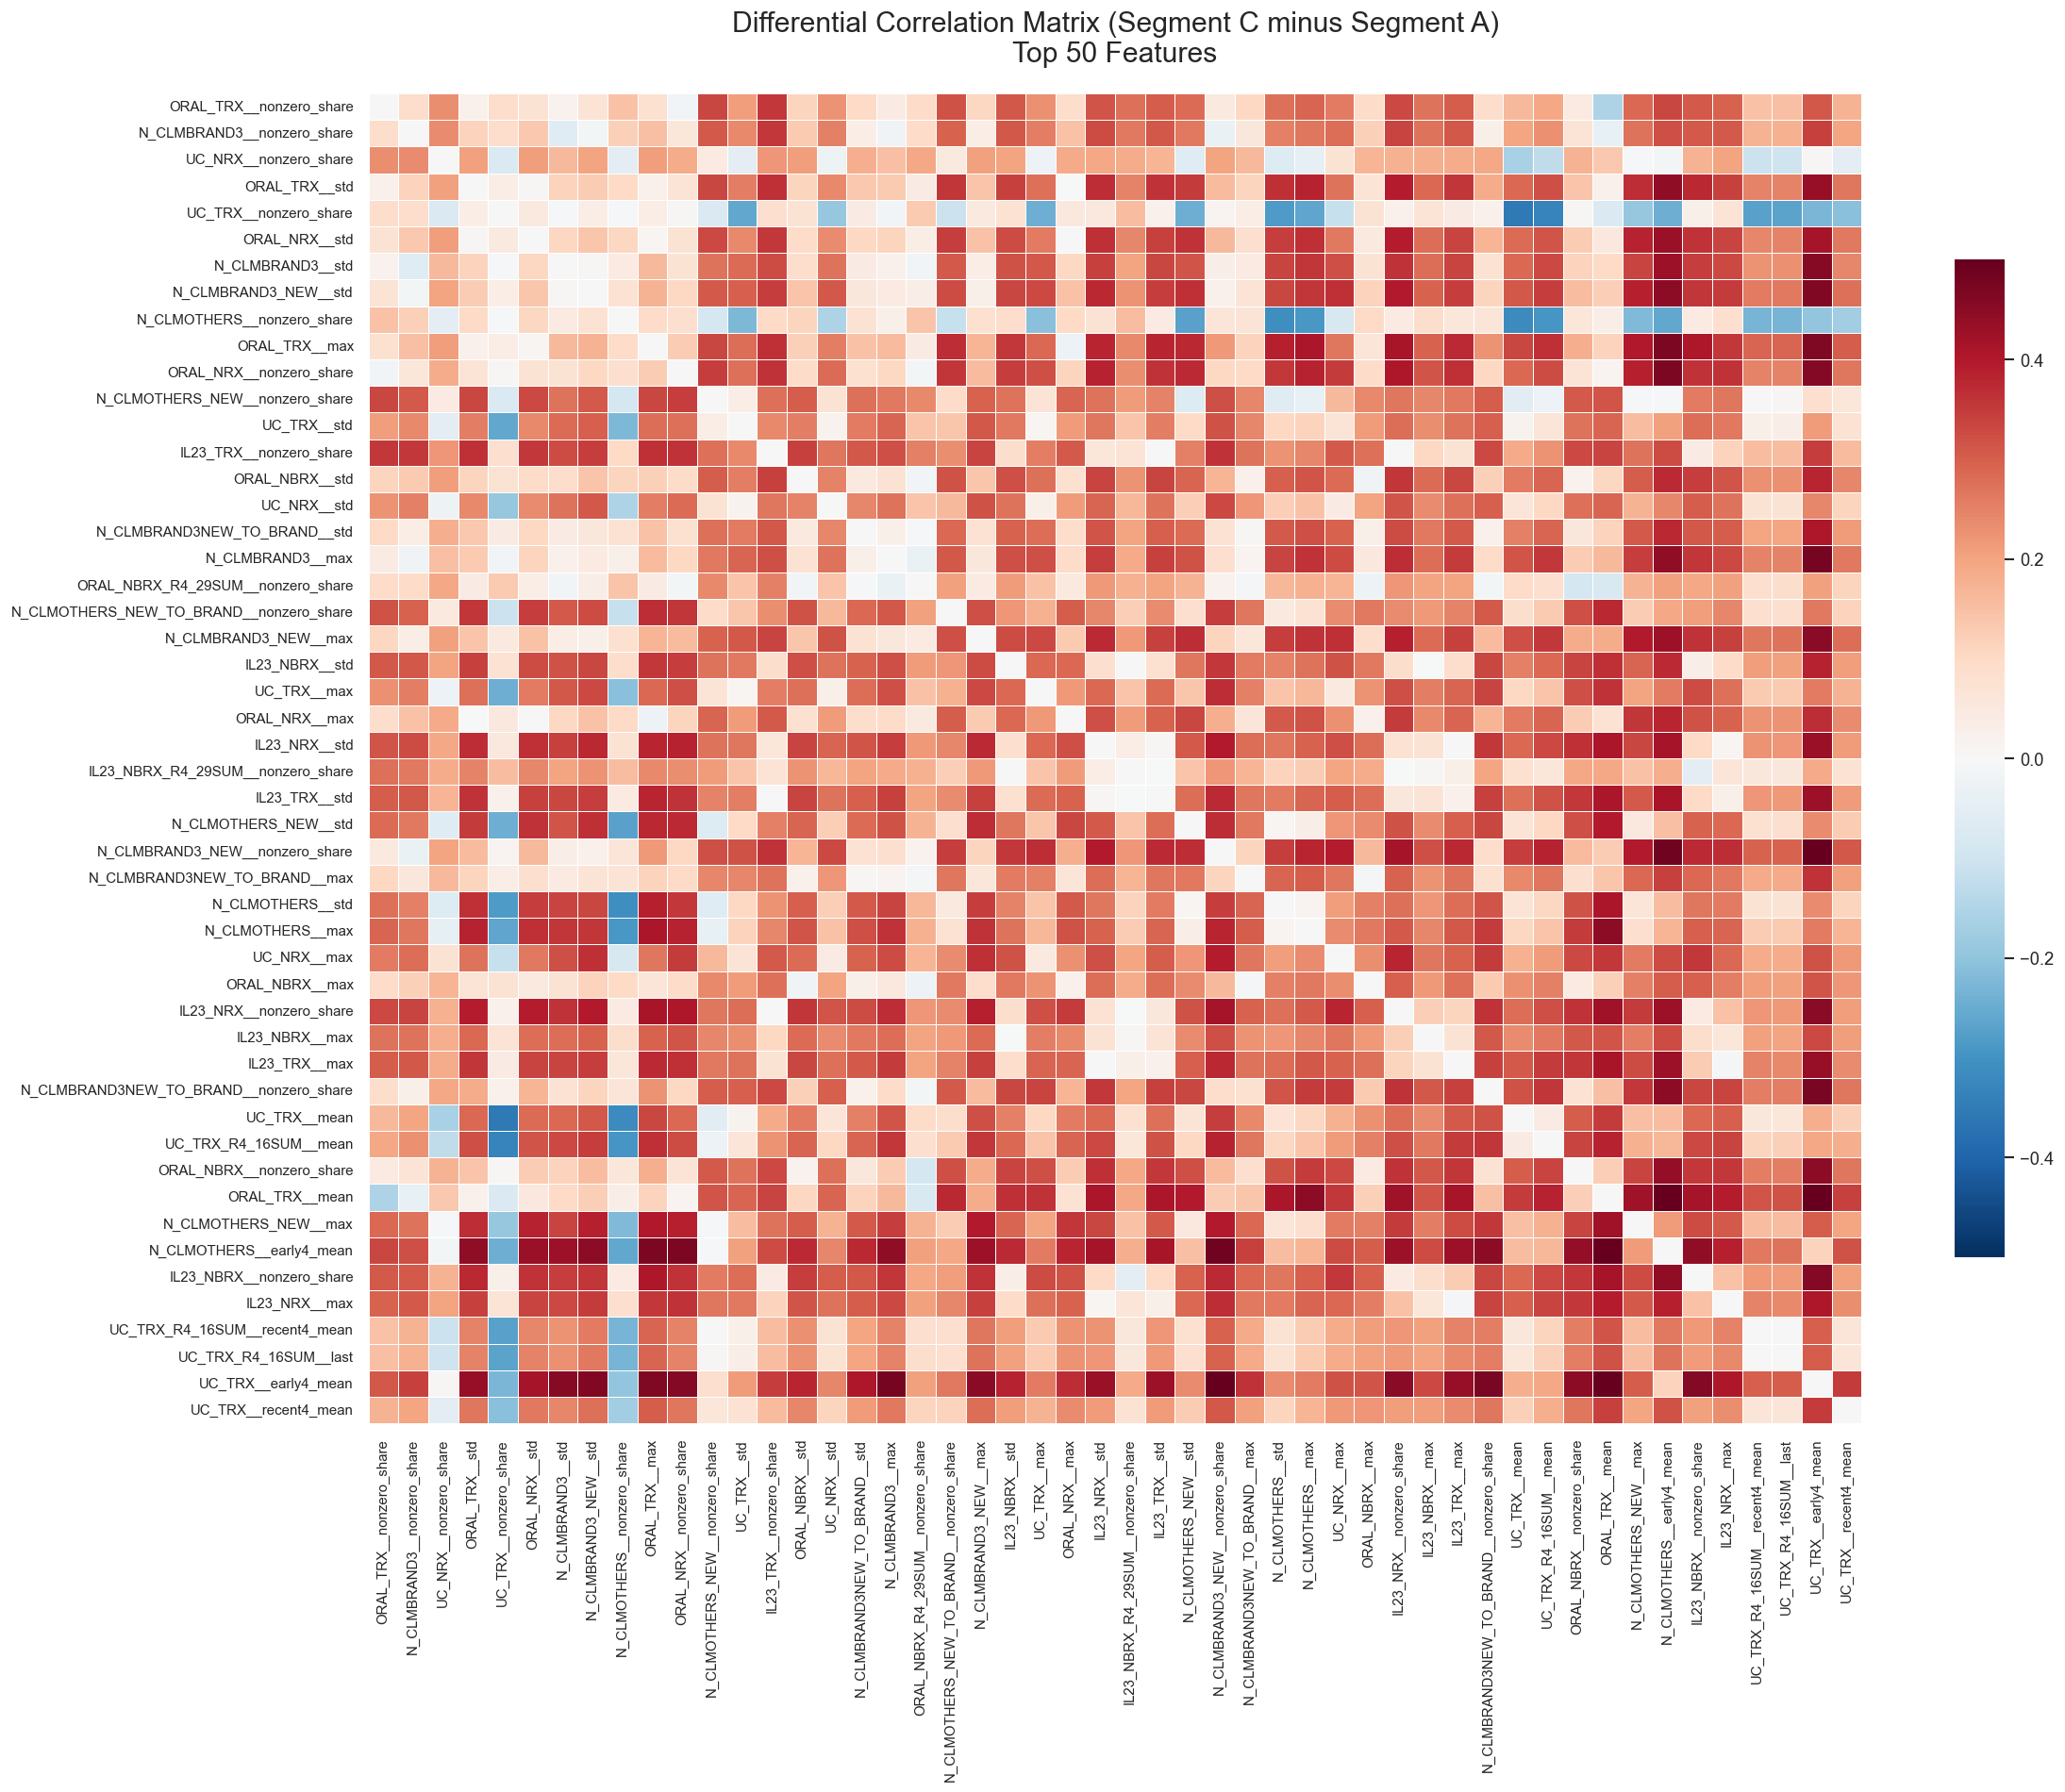

In [41]:
# Visualizing the Covariance Shift (Differential Correlation Matrix)
plt.figure(figsize=(20, 16))

# Using a diverging colormap since differences range from negative to positive
sns.heatmap(diff_corr, 
            cmap='RdBu_r', 
            center=0, 
            annot=False, 
            linewidths=0.5, 
            vmax=0.5, vmin=-0.5, 
            cbar_kws={"shrink": .75})

plt.title('Differential Correlation Matrix (Segment C minus Segment A)\nTop 50 Features', fontsize=18, pad=20)
plt.xticks(rotation=90, fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

### 3. Covariance Network Topology
This section visualizes the correlation matrix as a network graph to highlight the structural 'Covariance Shift' between the SEG_A segment and Segment C. Features are nodes, and strong correlations (absolute value > 0.5) are edges.

Extracting correlations for 'SEG_A' and 'SEG_C'


NameError: name 'G_a' is not defined

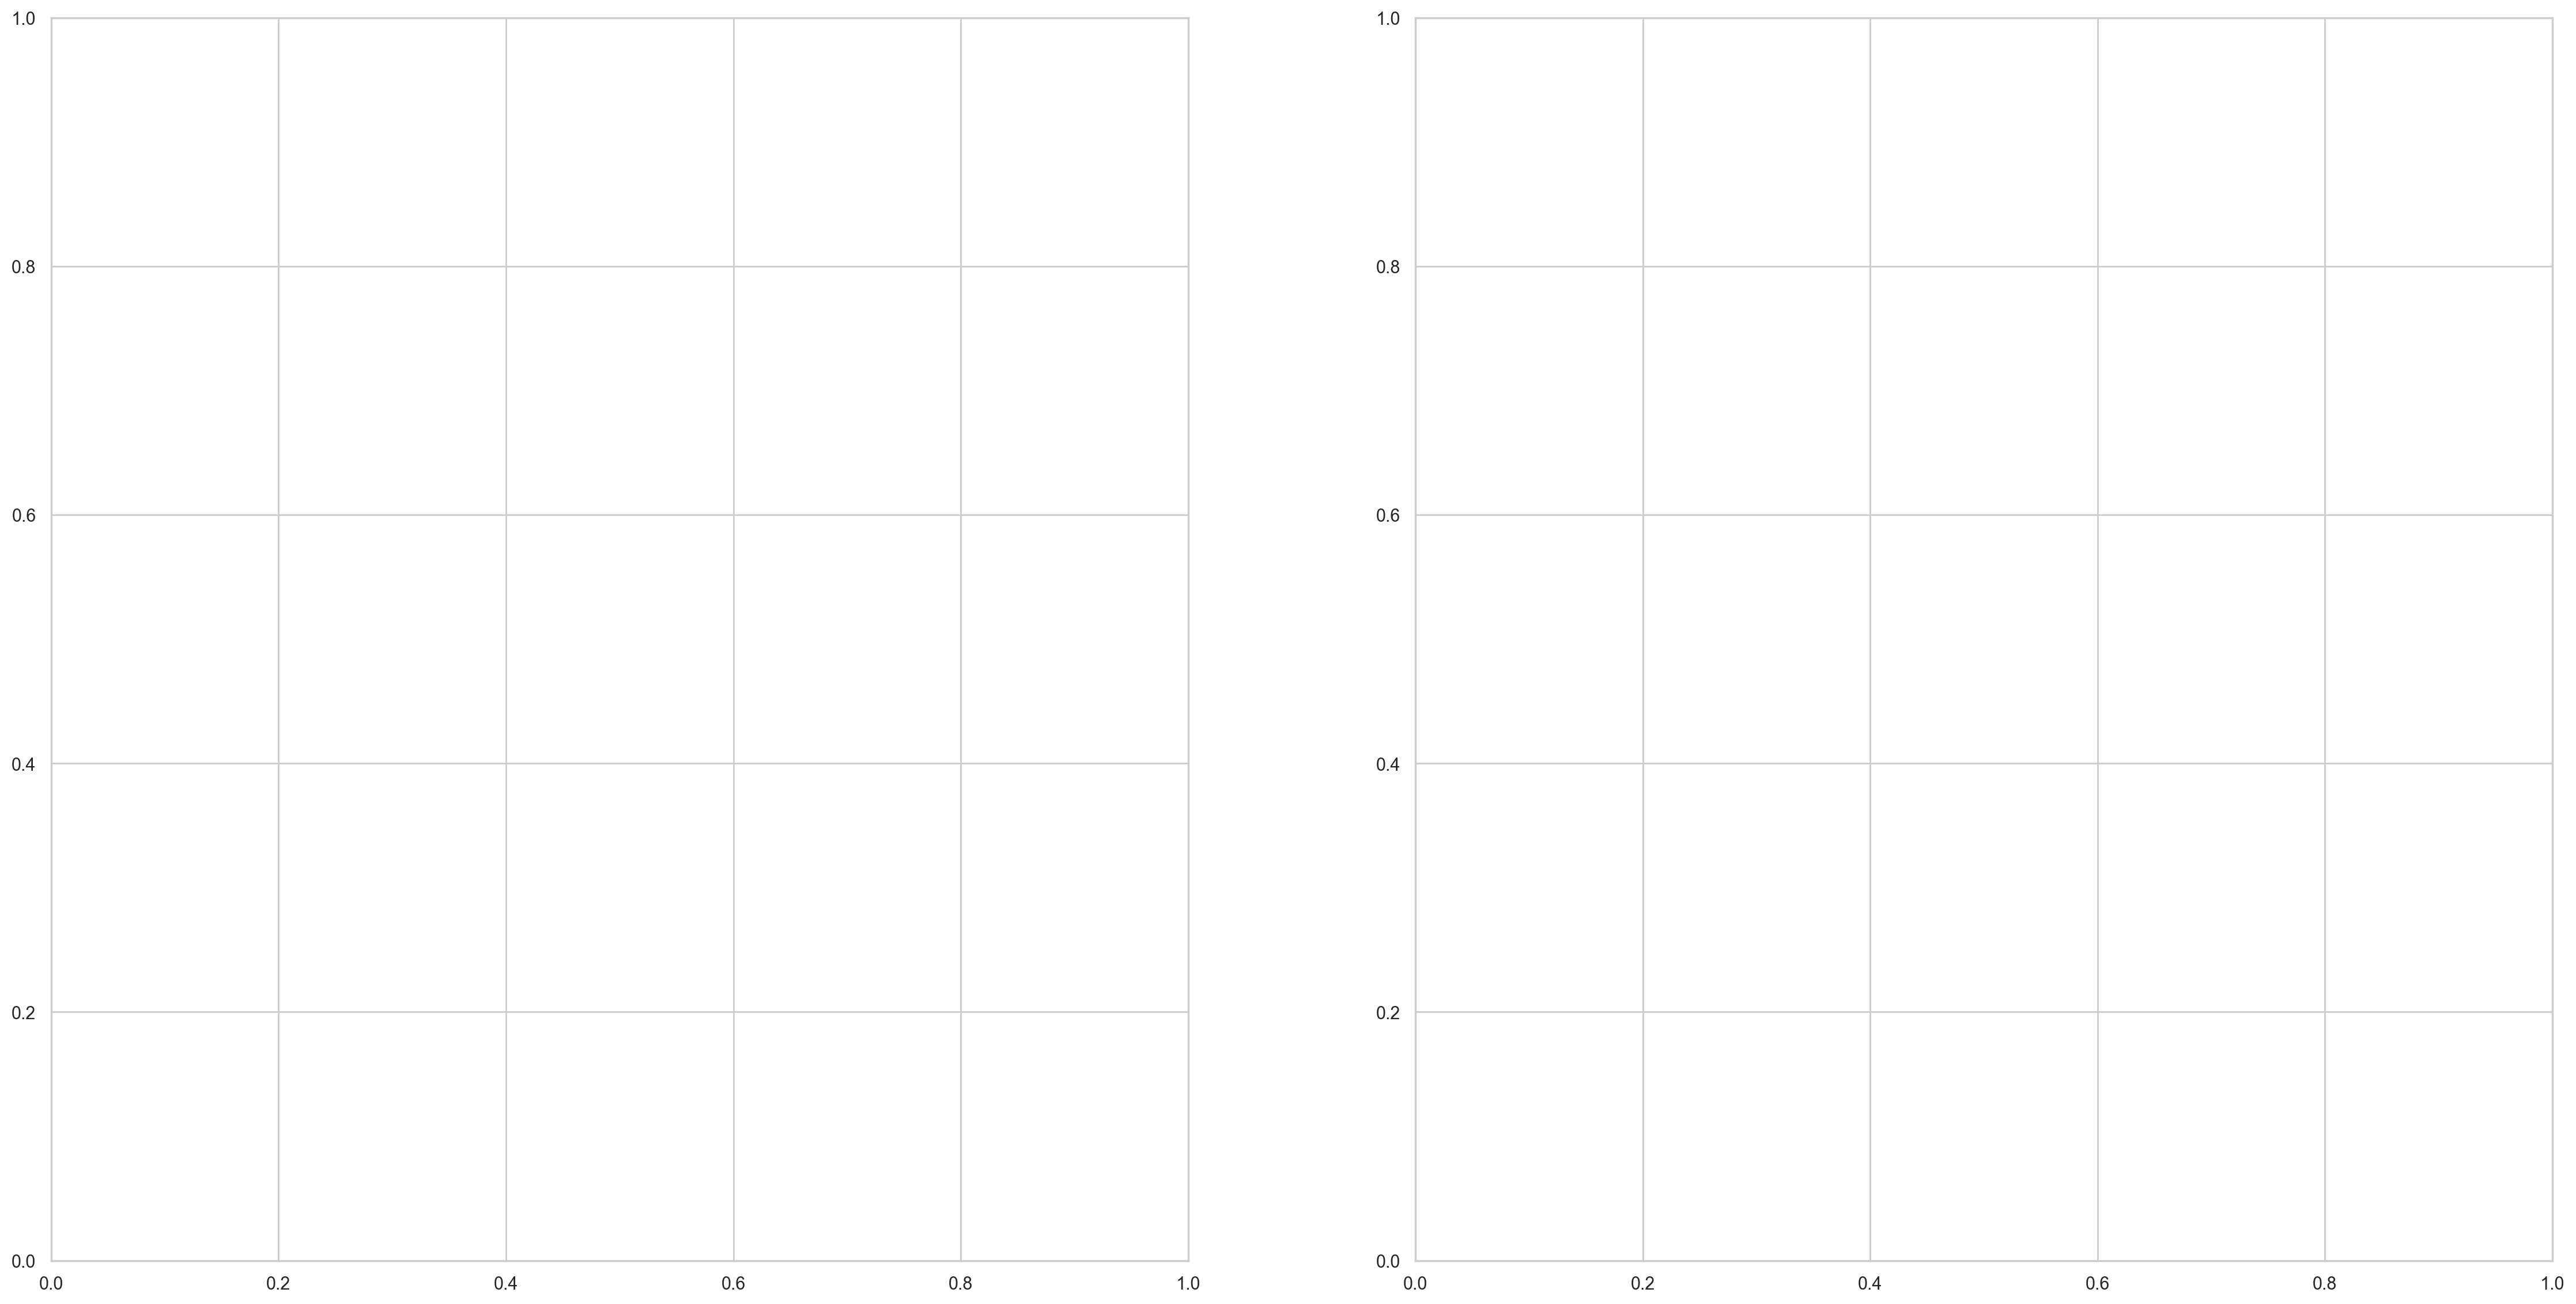

In [42]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib as mpl

def build_correlation_network(corr_matrix, threshold=0.65): # Increased threshold to reduce noise
    """
    Builds a NetworkX graph from a correlation matrix, creating edges 
    where the absolute correlation exceeds a strict threshold.
    """
    G = nx.Graph()
    features = corr_matrix.columns
    G.add_nodes_from(features)
    
    for i in range(len(features)):
        for j in range(i + 1, len(features)):
            weight = corr_matrix.iloc[i, j]
            if abs(weight) > threshold:
                G.add_edge(features[i], features[j], weight=weight)
    
    # Remove isolated nodes (features with no strong correlations) to clean up the plot
    isolated_nodes = list(nx.isolates(G))
    G.remove_nodes_from(isolated_nodes)
    
    return G

# Dynamically identify the UNLABELED and Segment C classes
class_a = 'SEG_A'
class_c = 'SEG_C'
class_b = 'SEG_B'

print(f"Extracting correlations for '{class_a}' and '{class_c}'")
df_a = X[y == class_a][top_50_features]
df_seg_c = X[y == class_c][top_50_features]

corr_a = df_a.corr()
corr_seg_c = df_seg_c.corr()

# Using a stricter threshold to avoid the 'hairball' effect
STRICT_THRESHOLD = 0.65
G_a = build_correlation_network(corr_a, threshold=STRICT_THRESHOLD)
G_seg_c = build_correlation_network(corr_seg_c, threshold=STRICT_THRESHOLD)

# Plotting with a larger figure size
fig, axes = plt.subplots(1, 2, figsize=(28, 14), dpi=200) # Increased figure size and DPI

# Create union for consistent layout, but apply strong repulsion (k)
G_union = nx.compose(G_a, G_seg_c)
# 'k' controls the distance between nodes. Higher k = nodes are pushed further apart.
pos = nx.spring_layout(G_union, seed=42, k=0.9, iterations=100) 

# Create manual colormap for NumPy 2.0 compatibility
cmap = plt.cm.RdBu_r
norm = mpl.colors.Normalize(vmin=-1, vmax=1)
mapper = plt.cm.ScalarMappable(norm=norm, cmap=cmap)

# --- Left Plot: UNLABELED ---
# Draw nodes
nx.draw_networkx_nodes(G_a, pos, ax=axes[0], node_size=300, node_color='#89CFF0', edgecolors='white')
# Draw edges
edges_unlabeled = G_a.edges(data=True)
if edges_unlabeled:
    manual_colors_unlabeled = [mapper.to_rgba(d['weight']) for u, v, d in edges_unlabeled]
    nx.draw_networkx_edges(G_a, pos, ax=axes[0], alpha=0.6, width=2.0, edge_color=manual_colors_unlabeled)
# Draw labels with smaller font
nx.draw_networkx_labels(G_a, pos, ax=axes[0], font_size=9, font_weight='bold')

axes[0].set_title(f'Covariance Topology: {class_a} Segment\n(Abs Corr > {STRICT_THRESHOLD})', fontsize=20, fontweight='bold', pad=20)
axes[0].axis('off')

# --- Right Plot: SEG C ---
# Draw nodes
nx.draw_networkx_nodes(G_seg_c, pos, ax=axes[1], node_size=300, node_color='#FA8072', edgecolors='white')
# Draw edges
edges_c = G_seg_c.edges(data=True)
if edges_c:
    manual_colors_c = [mapper.to_rgba(d['weight']) for u, v, d in edges_c]
    nx.draw_networkx_edges(G_seg_c, pos, ax=axes[1], alpha=0.6, width=2.0, edge_color=manual_colors_c)
# Draw labels with smaller font
nx.draw_networkx_labels(G_seg_c, pos, ax=axes[1], font_size=9, font_weight='bold')

axes[1].set_title(f'Covariance Topology: Segment {class_c}\n(Abs Corr > {STRICT_THRESHOLD})', fontsize=20, fontweight='bold', pad=20)
axes[1].axis('off')

# Add a colorbar at the bottom to explain the edge colors
cbar_ax = fig.add_axes([0.35, 0.05, 0.3, 0.02])
fig.colorbar(mapper, cax=cbar_ax, orientation='horizontal', label='Pearson Correlation')

plt.tight_layout(rect=[0, 0.08, 1, 1]) # Adjust layout to make room for colorbar
plt.show()

### 4. Top Structural Deltas (Correlation Shift Magnitude)
To pinpoint exactly which relationships change the most, we compute the absolute difference in correlation between Segment C and the SEG_A segment for every feature pair. The top 15 pairs with the highest shift are visualized below.

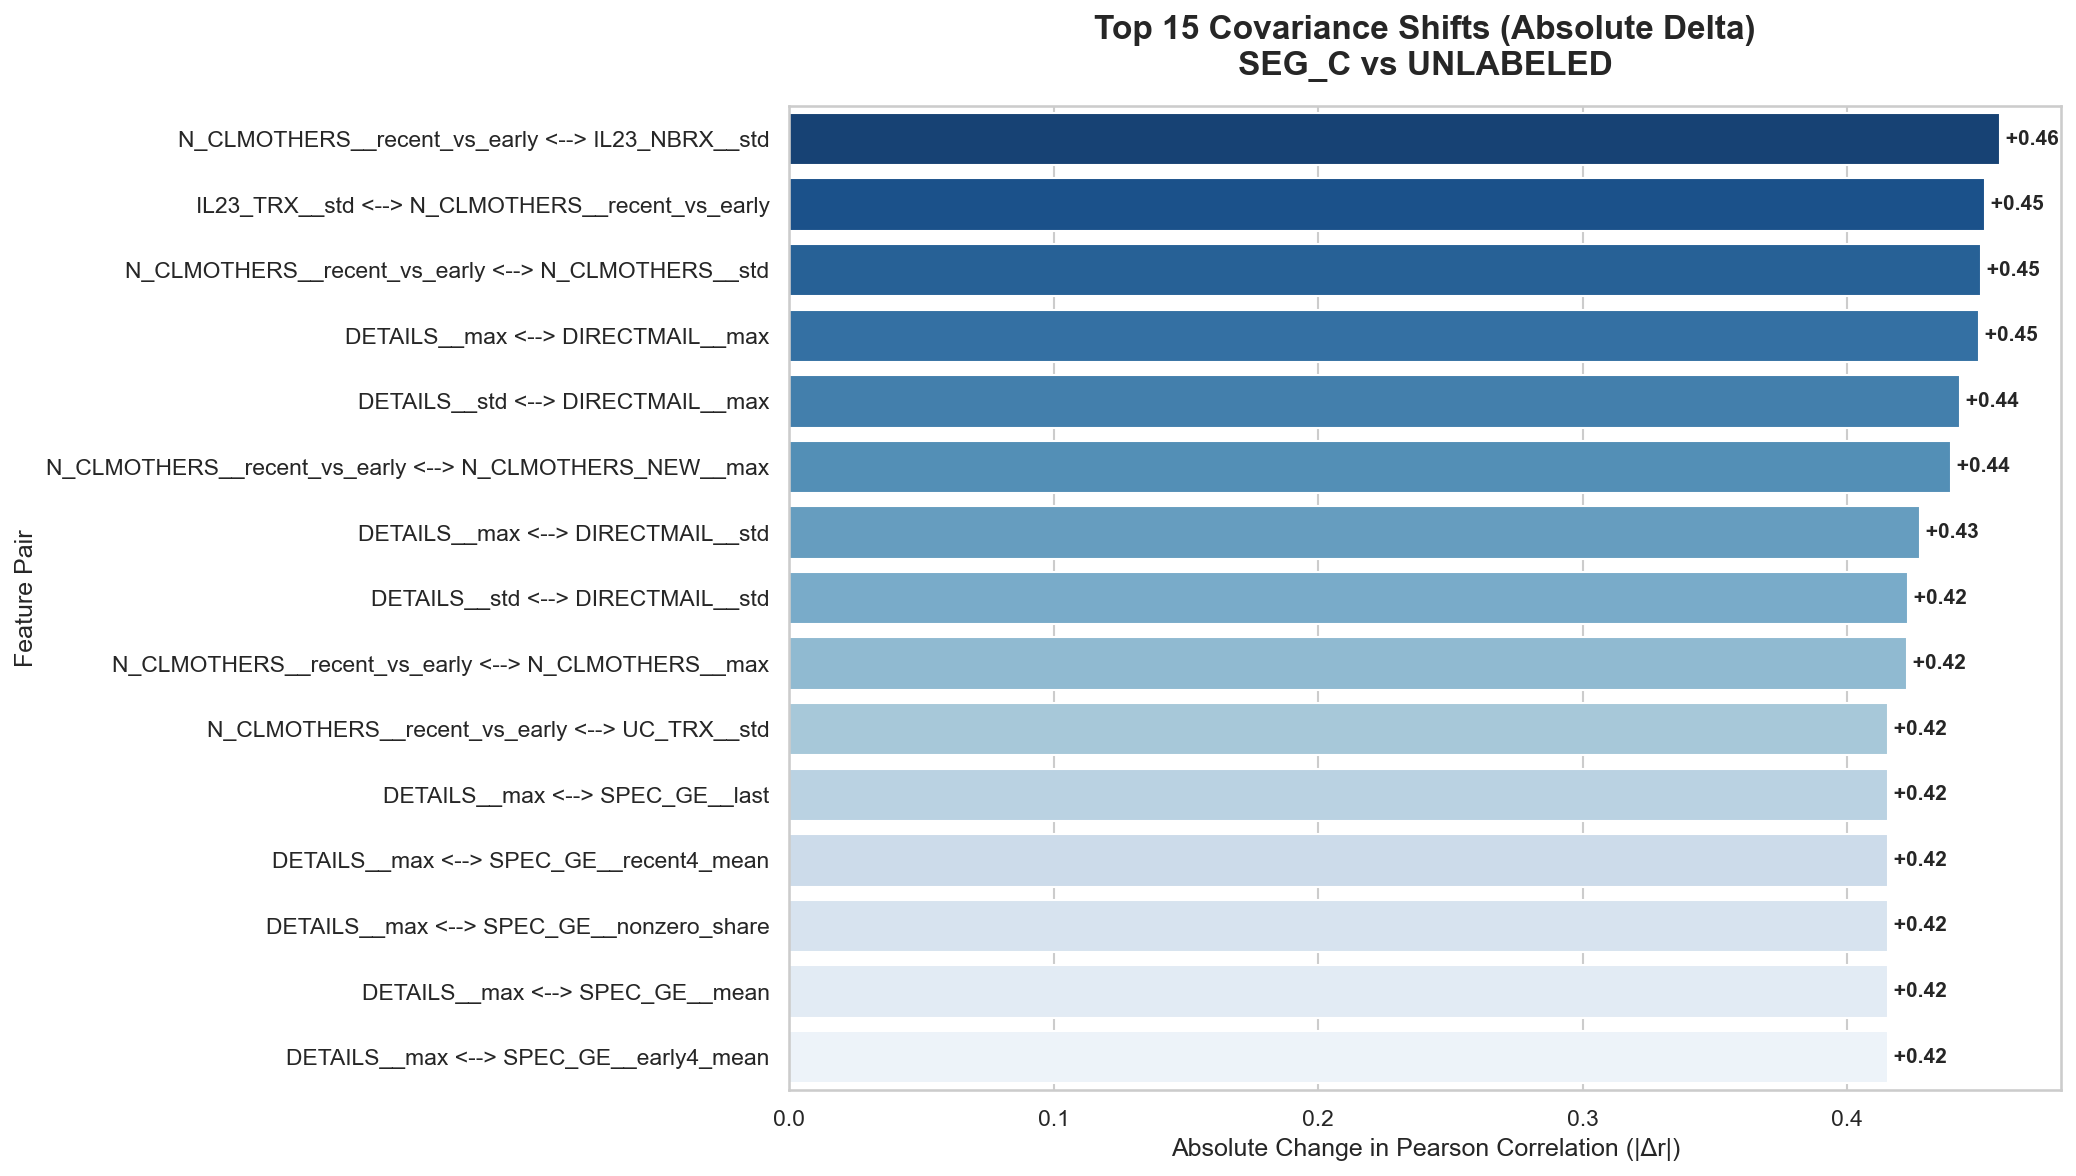

In [ ]:
# Calculate absolute differences between the two correlation matrices
delta_corr = (corr_seg_c - corr_a).abs()

# Extract upper triangle to avoid duplicate pairs
mask = np.triu(np.ones_like(delta_corr, dtype=bool), k=1)
delta_corr_triu = delta_corr.where(mask)

# Unstack to create a Series of pairs
delta_pairs = delta_corr_triu.unstack().dropna()
delta_pairs.index = [f"{f1} <--> {f2}" for f1, f2 in delta_pairs.index]

# Sort to get the top 15 shifts
top_deltas = delta_pairs.sort_values(ascending=False).head(15)

# Dumbbell Plot / Horizontal Bar Chart
plt.figure(figsize=(14, 8), dpi=150)
sns.barplot(x=top_deltas.values, y=top_deltas.index, palette='Blues_r')

plt.title(f'Top 15 Covariance Shifts (Absolute Delta)\n{class_c} vs {class_a}', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Absolute Change in Pearson Correlation (|Δr|)', fontsize=12)
plt.ylabel('Feature Pair', fontsize=12)

# Add value labels to the bars
for index, value in enumerate(top_deltas.values):
    plt.text(value, index, f' +{value:.2f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### 5. Interactive Topology (PyVis)
The static matplotlib graphs can suffer from the 'hairball' effect. Here we upgrade the `G_unlabeled` and `G_seg_c` NetworkX graphs into fully interactive HTML visualizations using the `pyvis` library, leveraging physics engines to elegantly repel nodes.

In [ ]:
# Note: If you don't have pyvis installed, you can install it via: !pip install pyvis
from pyvis.network import Network
import os

def create_interactive_network(nx_graph, output_filename, title, node_color):
    """
    Converts a NetworkX graph into an interactive PyVis HTML visualization.
    """
    # Initialize PyVis network
    net = Network(height='800px', width='100%', bgcolor='#ffffff', font_color='black', heading=title)
    
    # Configure the physics engine for elegant node repulsion
    net.barnes_hut(gravity=-8000, central_gravity=0.3, spring_length=150)
    
    # Add nodes with custom colors and hover tooltips
    for node in nx_graph.nodes():
        net.add_node(node, label=str(node), title=f"Feature: {node}", color=node_color, size=15)
        
    # Add edges with hover tooltips displaying the exact correlation weight
    for u, v, data in nx_graph.edges(data=True):
        weight = data.get('weight', 0)
        # Edge color based on positive (blue) or negative (red) correlation
        edge_color = '#1f77b4' if weight > 0 else '#d62728'
        # Edge thickness proportional to the absolute correlation
        edge_value = abs(weight) * 5
        net.add_edge(u, v, value=edge_value, title=f"Correlation: {weight:.3f}", color=edge_color)
        
    # Generate and save the HTML file
    net.save_graph(output_filename)
    print(f"Successfully saved interactive graph to: {output_filename}")

# Generate the SEG_A segment interactive graph
create_interactive_network(
    nx_graph=G_a, 
    output_filename='seg_a_topology.html', 
    title=f'Interactive Topology: {class_a} Segment', 
    node_color='#87CEFA' # Light blue
)

# Generate the SEG_C interactive graph
create_interactive_network(
    nx_graph=G_seg_c, 
    output_filename='seg_c_topology.html', 
    title=f'Interactive Topology: Segment {class_c}', 
    node_color='#FA8072' # Salmon
)

print("\nYou can now open 'seg_a_topology.html' and 'seg_c_topology.html' in any web browser!")

Successfully saved interactive graph to: unlabeled_topology.html
Successfully saved interactive graph to: seg_c_topology.html

You can now open 'unlabeled_topology.html' and 'seg_c_topology.html' in any web browser!


Calculating Correlation Deltas...


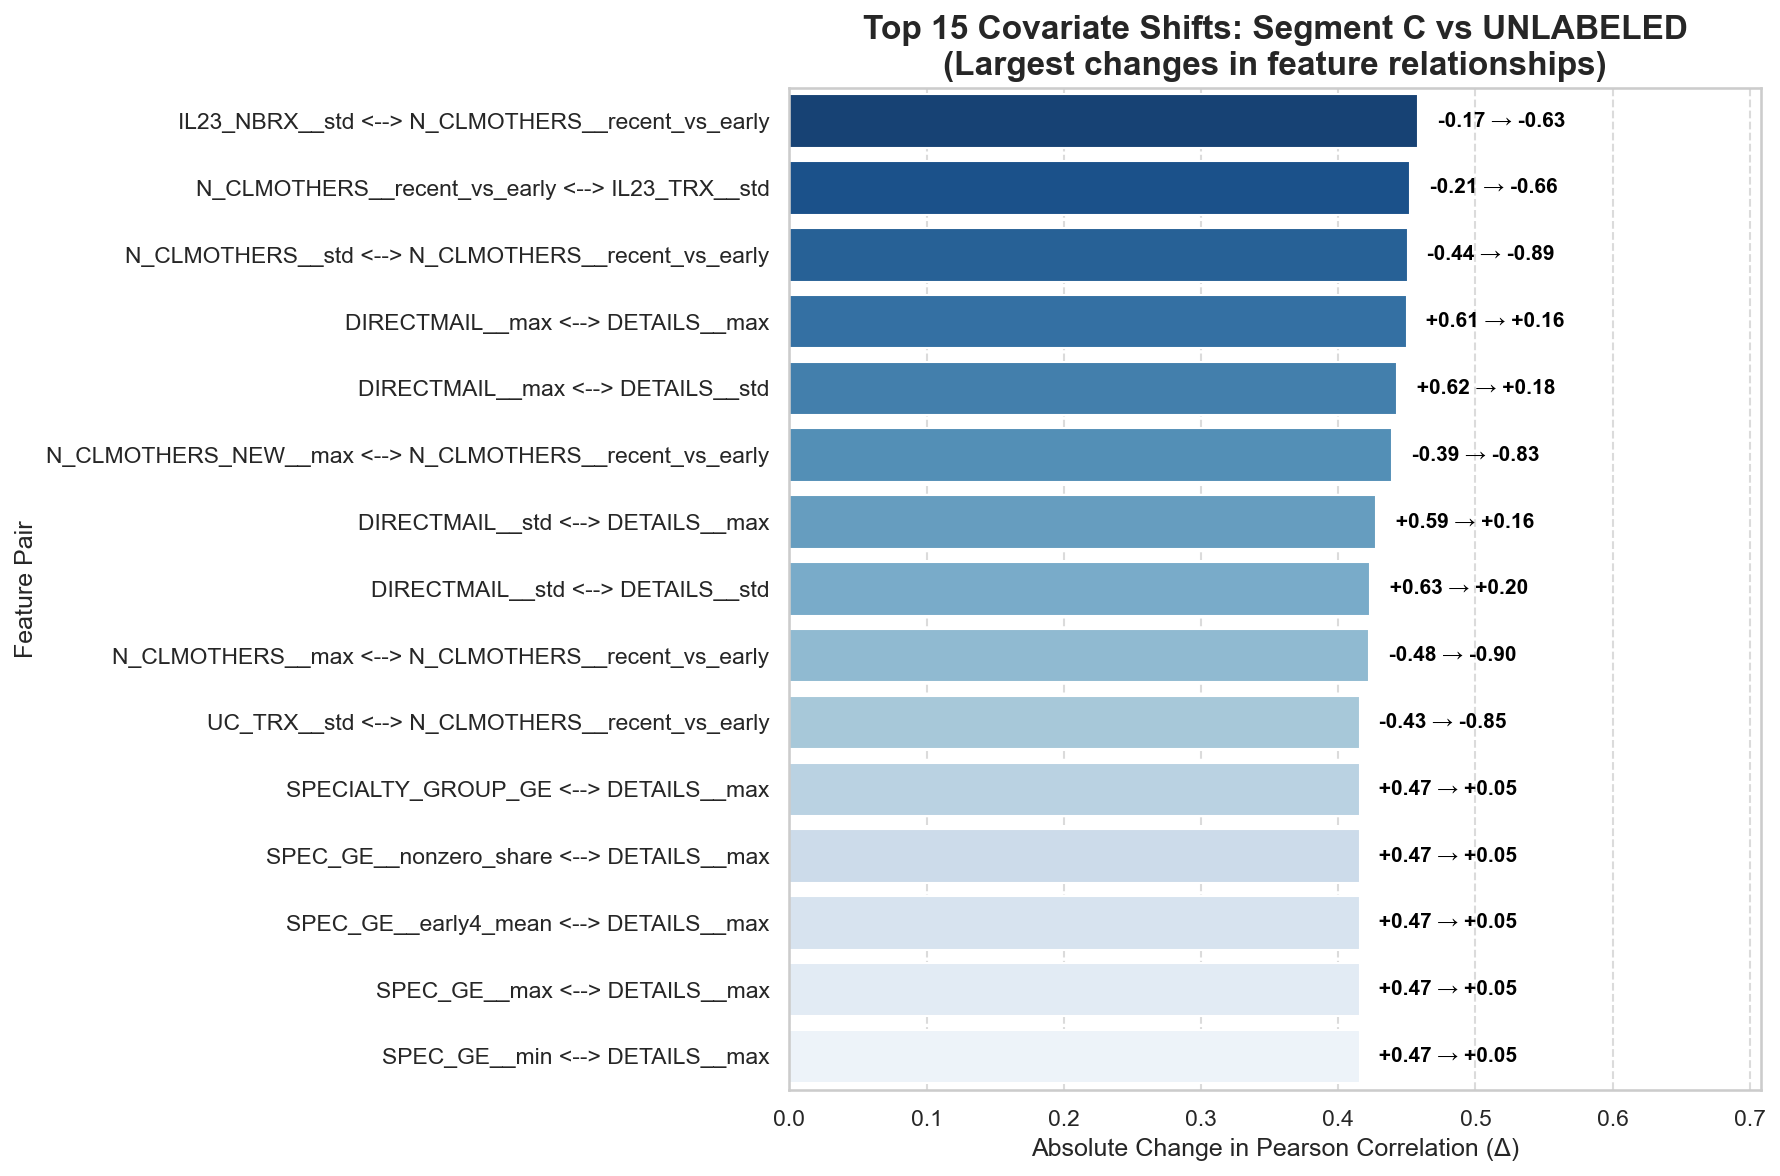

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming corr_a and corr_seg_c are already calculated from the previous steps
print("Calculating Correlation Deltas...")

# 1. Calculate the absolute difference between the two correlation matrices
delta_matrix = corr_seg_c - corr_a
abs_delta_matrix = delta_matrix.abs()

# 2. Extract the upper triangle to avoid duplicate pairs (A-B is the same as B-A)
# and ignore the diagonal (A-A is always 0)
upper_tri_indices = np.triu_indices_from(abs_delta_matrix, k=1)

# 3. Create a DataFrame with the pairwise differences
pairs = []
for i, j in zip(*upper_tri_indices):
    feature1 = abs_delta_matrix.index[i]
    feature2 = abs_delta_matrix.columns[j]
    delta_val = delta_matrix.iloc[i, j]
    abs_delta_val = abs_delta_matrix.iloc[i, j]
    
    pairs.append({
        'Feature_Pair': f"{feature1} <--> {feature2}",
        'Delta': delta_val,
        'Abs_Delta': abs_delta_val,
        'Corr_Unlabeled': corr_a.iloc[i, j],
        'Corr_Seg_C': corr_seg_c.iloc[i, j]
    })

delta_df = pd.DataFrame(pairs)

# 4. Sort by highest absolute shift and get the TOP 15
top_deltas = delta_df.sort_values(by='Abs_Delta', ascending=False).head(15)

# 5. Plotting the results (Dumbbell / Shift Plot)
plt.figure(figsize=(12, 8), dpi=150)

# Create a clean horizontal bar chart for the Absolute Deltas
sns.barplot(
    data=top_deltas, 
    x='Abs_Delta', 
    y='Feature_Pair', 
    palette='Blues_r'
)

plt.title('Top 15 Covariate Shifts: Segment C vs UNLABELED\n(Largest changes in feature relationships)', fontsize=16, fontweight='bold')
plt.xlabel('Absolute Change in Pearson Correlation (\u0394)', fontsize=12)
plt.ylabel('Feature Pair', fontsize=12)

# Add annotations to show the exact shift
for index, row in enumerate(top_deltas.itertuples()):
    shift_text = f" {row.Corr_Unlabeled:+.2f} \u2192 {row.Corr_Seg_C:+.2f}"
    plt.text(row.Abs_Delta + 0.01, index, shift_text, va='center', fontsize=10, fontweight='bold', color='black')

plt.xlim(0, top_deltas['Abs_Delta'].max() + 0.25) # Add padding for text
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()